In [1]:
from __future__ import annotations
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from scipy.special import logsumexp

In [2]:
def load_rgb_255(path: str) -> np.ndarray:
    """Load image as float32 RGB in [0,255], shape (H,W,3)"""
    im = Image.open(path).convert("RGB")
    return np.asarray(im, dtype=np.float32)

In [3]:
def make_features(img_255: np.ndarray, w_pos: float) -> np.ndarray:
    """
    Per-pixel feature vectors:
    [R,G,B, w_pos*px, w_pos*py] where px,py in [0,255] (global coords)
    Returns float64 array (N,d).
    """
    H, W, _ = img_255.shape
    rgb = img_255.reshape(-1, 3).astype(np.float64)

    ys = np.repeat(np.arange(H), W).astype(np.float64)  
    xs = np.tile(np.arange(W), H).astype(np.float64)    

    px = np.zeros_like(xs) if W == 1 else 255.0 * xs / (W - 1)
    py = np.zeros_like(ys) if H == 1 else 255.0 * ys / (H - 1)

    pos = np.stack([px, py], axis=1)  
    return np.concatenate([rgb, w_pos * pos], axis=1)  

In [4]:
def cost(A: np.ndarray, B: np.ndarray, chunk: int) -> np.ndarray:
    """
    Finds cost (squared euclidean) between A and B.
    Uses chunking over A to control memory.
    Returns C shape (n,m), float64.
    """
    n, d = A.shape
    m, _ = B.shape
    C = np.empty((n, m), dtype=np.float64)
    B2 = np.sum(B * B, axis=1, keepdims=True).T  
    print(f"[1/4] Building cost matrix C (shape {n}x{m})")

    for start in range(0, n, chunk):
        end = min(start + chunk, n)
        A_chunk = A[start:end]
        A2 = np.sum(A_chunk * A_chunk, axis=1, keepdims=True)  
        #||a-b||^2=||a||^2+||b||^2-2a^Tb
        C_chunk = A2 + B2 - 2.0 * (A_chunk @ B.T)
        C[start:end] = np.maximum(C_chunk, 0.0)

    return C

In [5]:
def sinkhorn_log(a: np.ndarray, b: np.ndarray, C: np.ndarray, eps: float,
                      max_iters: int, tol: float, check_every: int) -> tuple[np.ndarray, float, int]:
    """
    Entropic OT via log-domain Sinkhorn.
    Returns (P, err, iters).
    """
    a = np.asarray(a, dtype=np.float64)
    b = np.asarray(b, dtype=np.float64)
    C = np.asarray(C, dtype=np.float64)

    n, m = C.shape
    loga = np.log(a)
    logb = np.log(b)
    logK = -C / float(eps)
    logu = np.ones(n, dtype=np.float64)
    logv = np.ones(m, dtype=np.float64)

    err = np.inf
    it = 0

    for it in range(1, max_iters + 1):
        logKv = logsumexp(logK + logv[None, :], axis=1)
        logu = loga - logKv
        logKTu = logsumexp(logK + logu[:, None], axis=0)
        logv = logb - logKTu

        if it % check_every == 0 or it == max_iters:
            logKv = logsumexp(logK + logv[None, :], axis=1)
            logKTu = logsumexp(logK + logu[:, None], axis=0)

            r = np.exp(logu + logKv)
            c = np.exp(logv + logKTu)

            err_a = np.sum(np.abs(r - a))
            err_b = np.sum(np.abs(c - b))
            err = float(max(err_a, err_b))

            if err < tol:
                break

    P = np.exp(logu[:, None] + logK + logv[None, :])
    return P, err, it

In [6]:
def nearest_neighbor_map(A: np.ndarray, B: np.ndarray, chunk: int) -> np.ndarray:
    """
    For each pixel in A, finds nearest pixel in B by squared Euclidean distance.
    Returns idx shape (N,), int.
    Chunked over A with progress.
    """
    N, d = A.shape
    M, _ = B.shape
    idx = np.empty(N, dtype=np.int64)

    B2 = np.sum(B * B, axis=1)  # (M,)

    print(f"[4/4] Nearest-neighbor mapping: {N} points -> {M} samples")

    for start in range(0, N, chunk):
        end = min(start + chunk, N)
        A_chunk = A[start:end]                  
        A2 = np.sum(A_chunk * A_chunk, axis=1)    
        D = A2[:, None] + B2[None, :] - 2.0 * (A_chunk @ B.T)
        idx[start:end] = np.argmin(D, axis=1)

    return idx

In [7]:
def save_rgb_255(path: str, img_255: np.ndarray) -> None:
    """Save float image to disk as uint8"""
    img = np.clip(img_255, 0, 255).astype(np.uint8)
    Image.fromarray(img, mode="RGB").save(path)

In [8]:
def display_triptych(src_255: np.ndarray, tgt_255: np.ndarray, out_255: np.ndarray,
                     titles=("Source", "Target", "Output")) -> None:
    """Display source/target/output"""

    fig, axes = plt.subplots(1, 3, figsize=(14, 5))
    for ax, img, title in zip(axes, [src_255, tgt_255, out_255], titles):
        ax.imshow(np.clip(img, 0, 255).astype(np.uint8))
        ax.set_title(title)
        ax.axis("off")
    plt.tight_layout()
    plt.show()
    return

In [9]:
def colour_transfer(src_path: str, tgt_path: str, out_path: str, 
                       eps: float, sinkhorn_iters: int, sinkhorn_tol: float, check_every: int, 
                       w_pos: float, 
                       ns: int, nt: int, seed: int, 
                       cost_chunk: int, nn_chunk: int) -> None:
    """
    Run global OT colour transfer and save output.
    """
    rng = np.random.default_rng(seed)

    src = load_rgb_255(src_path)
    tgt = load_rgb_255(tgt_path)

    Hs, Ws, _ = src.shape
    Ht, Wt, _ = tgt.shape
    print(f"Source: {Hs}x{Ws}, Target: {Ht}x{Wt}")

    Xs = make_features(src, w_pos)
    Xt = make_features(tgt, w_pos)

    Ns = Xs.shape[0]
    Nt = Xt.shape[0]
    ns_eff = min(ns, Ns)
    nt_eff = min(nt, Nt)
    print(f"[0/4] Sampling pixels for OT: ns={ns_eff}/{Ns}, nt={nt_eff}/{Nt} (seed={seed})")

    idx_s = rng.choice(Ns, size=ns_eff, replace=False)
    idx_t = rng.choice(Nt, size=nt_eff, replace=False)
    Xs_s = Xs[idx_s]  
    Xt_t = Xt[idx_t]  
    a = np.full(ns_eff, 1.0 / ns_eff, dtype=np.float64)
    b = np.full(nt_eff, 1.0 / nt_eff, dtype=np.float64)

    C = cost(Xs_s, Xt_t, cost_chunk)
    P, err, iters = sinkhorn_log(a, b, C, eps, sinkhorn_iters, sinkhorn_tol, check_every)

    print(f"[3/4] Barycentric projection to colours (Sinkhorn iters={iters}, final err={err:.3e})")

    tgt_rgb = tgt.reshape(-1, 3).astype(np.float64)
    Y = tgt_rgb[idx_t]  
    row_sums = np.maximum(P.sum(axis=1, keepdims=True), 1e-12)
    barycentric_rgb_samples = (P @ Y) / row_sums  

    nn = nearest_neighbor_map(Xs, Xs_s, nn_chunk)  
    out_rgb = barycentric_rgb_samples[nn].reshape(Hs, Ws, 3).clip(0, 255).astype(np.float32)

    save_rgb_255(out_path, out_rgb)
    print(f"Done. Saved: {out_path}")
    display_triptych(src, tgt, out_rgb, titles=("Source", "Target", "Output"))

Source: 408x612, Target: 408x612
[0/4] Sampling pixels for OT: ns=6000/249696, nt=6000/249696 (seed=0)
[1/4] Building cost matrix C (shape 6000x6000)
[3/4] Barycentric projection to colours (Sinkhorn iters=100, final err=7.178e-01)
[4/4] Nearest-neighbor mapping: 249696 points -> 6000 samples
Done. Saved: output1.jpg


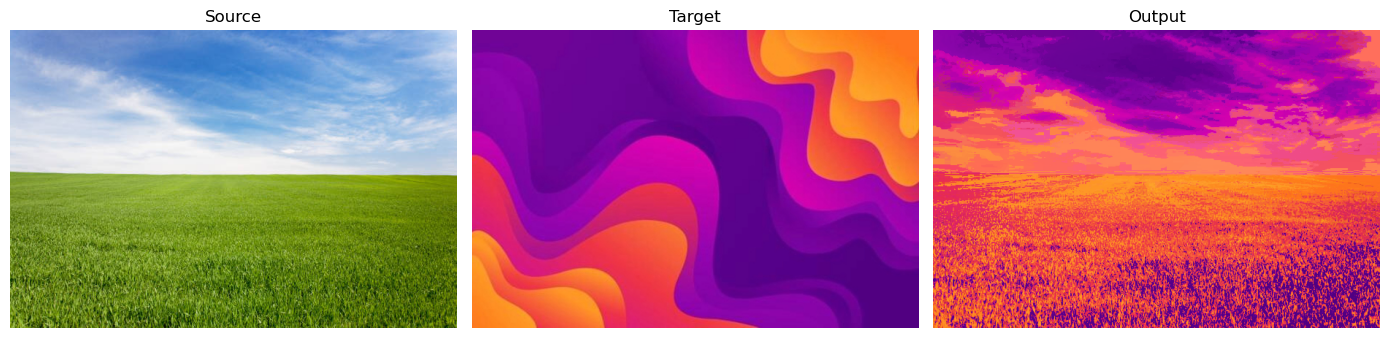

In [10]:
colour_transfer("field1.jpg", "orangepurple.jpg", "output1.jpg", 
                eps=10.0, sinkhorn_iters=100, 
                sinkhorn_tol=1e-6, check_every=25, 
                w_pos=0.5, 
                ns=6000, nt=6000, seed=0,
                cost_chunk=2048, nn_chunk=8192)

Source: 408x612, Target: 408x612
[0/4] Sampling pixels for OT: ns=6000/249696, nt=6000/249696 (seed=0)
[1/4] Building cost matrix C (shape 6000x6000)
[3/4] Barycentric projection to colours (Sinkhorn iters=100, final err=6.845e-01)
[4/4] Nearest-neighbor mapping: 249696 points -> 6000 samples
Done. Saved: output1.jpg


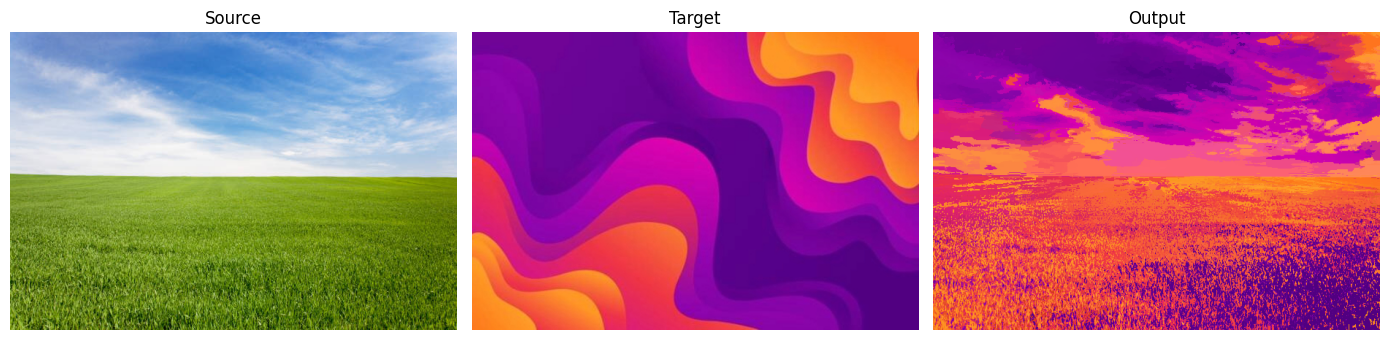

In [10]:
colour_transfer("field1.jpg", "orangepurple.jpg", "output1.jpg", 
                eps=10.0, sinkhorn_iters=100, 
                sinkhorn_tol=1e-6, check_every=25, 
                w_pos=1, 
                ns=6000, nt=6000, seed=0,
                cost_chunk=2048, nn_chunk=8192)

Source: 408x612, Target: 408x612
[0/4] Sampling pixels for OT: ns=6000/249696, nt=6000/249696 (seed=0)
[1/4] Building cost matrix C (shape 6000x6000)
[3/4] Barycentric projection to colours (Sinkhorn iters=100, final err=4.729e-01)
[4/4] Nearest-neighbor mapping: 249696 points -> 6000 samples
Done. Saved: output2.jpg


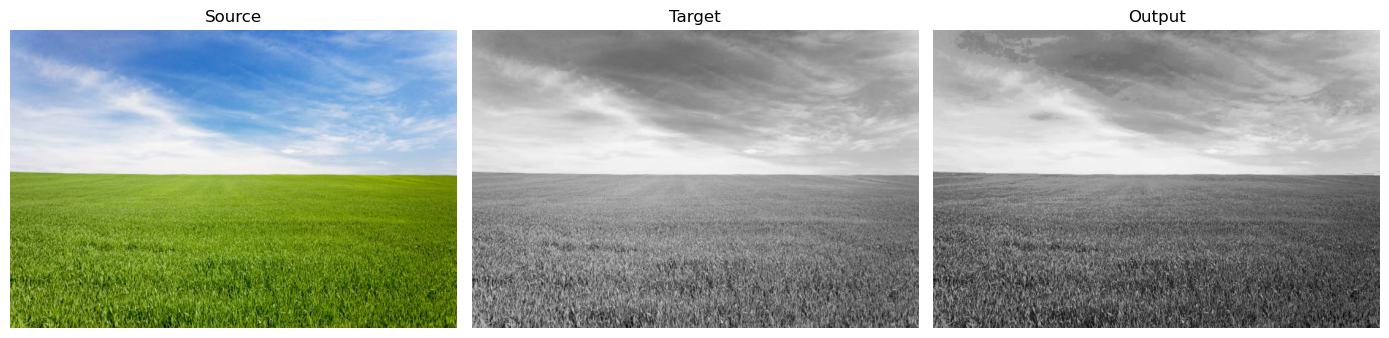

In [11]:
colour_transfer("field1.jpg", "field2.jpg", "output2.jpg", 
                eps=10.0, sinkhorn_iters=100, 
                sinkhorn_tol=1e-6, check_every=25, 
                w_pos=0.5, 
                ns=6000, nt=6000, seed=0,
                cost_chunk=2048, nn_chunk=8192)

Source: 408x612, Target: 408x612
[0/4] Sampling pixels for OT: ns=6000/249696, nt=6000/249696 (seed=0)
[1/4] Building cost matrix C (shape 6000x6000)
[3/4] Barycentric projection to colours (Sinkhorn iters=100, final err=4.174e-01)
[4/4] Nearest-neighbor mapping: 249696 points -> 6000 samples
Done. Saved: output3.jpg


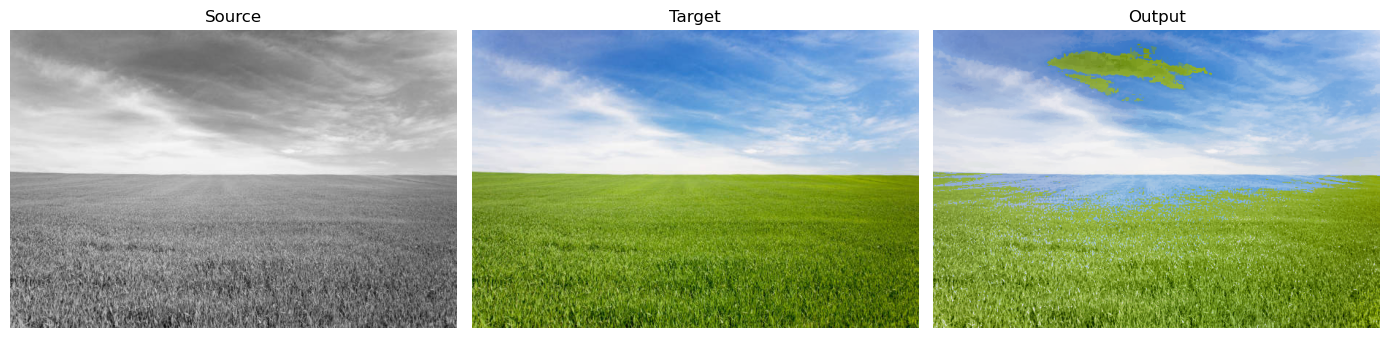

In [12]:
colour_transfer("field2.jpg", "field1.jpg", "output3.jpg", 
                eps=10.0, sinkhorn_iters=100, 
                sinkhorn_tol=1e-6, check_every=25, 
                w_pos=0.5, 
                ns=6000, nt=6000, seed=0,
                cost_chunk=2048, nn_chunk=8192)

Source: 408x612, Target: 408x612
[0/4] Sampling pixels for OT: ns=6000/249696, nt=6000/249696 (seed=0)
[1/4] Building cost matrix C (shape 6000x6000)
[3/4] Barycentric projection to colours (Sinkhorn iters=100, final err=8.601e-01)
[4/4] Nearest-neighbor mapping: 249696 points -> 6000 samples
Done. Saved: output4.jpg


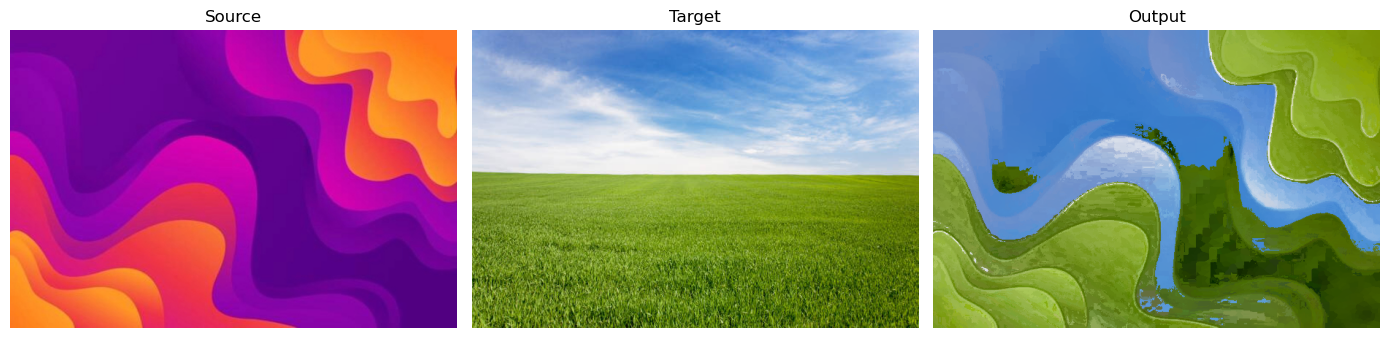

In [14]:
colour_transfer("orangepurple.jpg", "field1.jpg", "output4.jpg", 
                eps=10.0, sinkhorn_iters=100, 
                sinkhorn_tol=1e-6, check_every=25, 
                w_pos=0.5, 
                ns=6000, nt=6000, seed=0,
                cost_chunk=2048, nn_chunk=8192)